# 核心资产 ETF 动量轮动策略

我们即将通过一个经典的“动量轮动交易”框架，从零开始用 Python 构建一个动态切换持有最强资产的量化策略，并在 A 股与海外核心大类资产上完成历史回测。

---

# 1. 策略基本面与底层逻辑

### 什么是动量效应 (Momentum) 与轮动策略 (Rotation)？
在金融市场中，“动量效应”被通俗地描述为“强者恒强，弱者恒弱”。即过去一段时间表现好的资产，受到资金追捧与共识惯性，在未来一段时间内有大概率继续表现良好。
“轮动策略”的核心思想是**不把鸡蛋放在同一个篮子里，但也绝不在烂苹果上浪费资金**。我们会在一组精选的、相关性较低的核心大类资产池中，定期计算它们的“**动量（即上涨趋势的强弱）**”，并将资金全仓动态买入当前势头最猛的那一个，进而吃掉它最肥美的一段波段。如果风口转换，我们就立刻切仓。

### 策略设计规则
为了让策略具备抗风险能力和全天候作战能力，我们在资产池的配置上兼顾了“避险”、“宽基成长”和“海外”四个低相关维度：
1. **资产精选池**：
   - 黄金 ETF (**518880**, 避险保底工具)
   - 纳指 100 ETF (**513100**, 海外科技龙头)
   - 创业板 100 ETF (**159915**, 国内成长股与新能源)
   - 上证 180 ETF (**510180**, 国内金融蓝筹与价值)

2. **动量因子如何判断**：我们如何用严谨的数学定义“强”？绝对不仅仅是看收益率高低，还要看这种涨幅是否“稳健平滑”。在这里，我们选用过去一段时间内的价格序列进行数学回归：
   - 先对过去 `25` 天的收盘价取对数后进行一元线性回归。
   - **综合动量得分 = 拟合年化收益率 $\times$ 判定系数 $R^2$**
   - *（$R^2$ 代表了资产价格向着预期均线稳定贴合爬升程度。这个组合公式意味着那些既具备高收益，又表现得如一条平滑美丽直线、稳步上扬的标的将会获胜。）*

3. **交易逻辑**：
   - 每天收盘后对这 4 个 ETF 进行上述的动量计分与大比较。
   - 找出最高分的那一个，选作明日标的。
   - 第二天全仓买入，持有享受涨幅，直至它失利离场。

接下来，我们将从数据加载开始，一步一步用纯代码还原这套交易系统。

---
## 第一步：加载资产池数据
导入所需的 Pandas 数据处理模块并读取前序收集到的复权面数据，将其平齐拼接对齐为一个完整宽表。

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import math

# 配置 matplotlib 以支持中文字体显示
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False 

# 加载数据
data_dir = 'data'
etf_pool = {
    '518880': '黄金ETF',
    '513100': '纳指100',
    '159915': '创业板100',
    '510180': '上证180'
}

dfs = []
for code, name in etf_pool.items():
    file_path = os.path.join(data_dir, f"{code}.csv")
    if os.path.exists(file_path):
        df = pd.read_csv(file_path)
        # 读取米筐产生的新格式（如 2014-01-02）
        df['date'] = pd.to_datetime(df['date'].astype(str))
        df.set_index('date', inplace=True)
        # 提取收盘价，并以 ETF 代码作为列名
        df_close = df[['close']].rename(columns={'close': code})
        dfs.append(df_close)
    else:
        print(f"数据文件不存在: {file_path}")

# 合并所有ETF的收盘价，使用 inner join （或 ffill）来对齐交易日
close_prices = pd.concat(dfs, axis=1).ffill().dropna()
print("数据前 5 行：")
display(close_prices.head())
print(f"总交易天数: {len(close_prices)}")

数据前 5 行：


,518880,513100,159915,510180
date,,,,
2014-01-02,0.907406,1.169,1.496141,2.023668
2014-01-03,0.915336,1.161,1.517907,1.992457
2014-01-06,0.919490,1.157,1.488121,1.954199
2014-01-07,0.922133,1.156,1.516761,1.948158
2014-01-08,0.910427,1.173,1.575186,1.955206


总交易天数: 2966


# 2. 动量因子 (Momentum Factor) 的底层计算

在获取到平齐的每天收盘价序列之后，我们需要构建一套冷酷无情的打分系统。  
如果作为趋势跟踪者只看绝对收益率（比如头尾相除上涨了百分之多少），很容易被某一天极其异常的暴涨所误导。**因此，真正的量化趋势跟踪，不仅要喜欢“涨得多的”，更要求它是“每天脚踏实地慢慢涨的，无巨大回撤波折（低波动线性增长）”。**

### 因子设计原理：基于对数收益率的回归打分框架

#### 核心操作 1：为什么必须先对价格取“自然对数 ($\ln$)”？
初学者最大的认知误区就是直接给原始股价画直线。要明白，真实的跨期策略是“复利（利滚利）”累加的增长模式。如果一个完美的资产每天稳定上涨 2%，它形成的绝对不是一根几何直线，而是一条越飙越快并朝天扬起的**复利指数抛物线**。若用直线去拟合这根抛物线，计算结果不仅残差极大，连 $R^2$ 都会受损，导致系统错误错杀这只会下蛋的好母鸡。
**而对数操作（Log）犹如一套数学上的降维打击，它能物理性地将弯曲的乘法复利曲线，硬生生地拉扯为一条可拟合的平滑直线。**

#### 核心操作 2：线性回归萃取指标
在价格被完美拉平后，利用 25 天的历史序列进行**普通最小二乘法 (OLS) 一元线性回归**，强行抽出下面两个王牌数据指标：
1. **回归直线的斜率 (Slope)**：随后换算为 `年化收益率`，这单纯反映了这支资产宏观上行的动能到底极其多狂暴。
2. **判定系数 ($R^2$)**：这是系统安全的核心，它衡量这条理想拟合直线有多大概率能完美代表现实。$R^2$ 越靠近 `1.0`，说明现实价格无视一切宏观阴霾，踏步式抗震荡向上；越靠近 `0.0` 则说明其走势全是过山车和各种骗炮洗盘，充满主力的恶意。

因此我们将计算它们的乘积：
$$ \text{最终综合得分} = \text{Annualized Returns (年化收益)} \times R^2 $$
用这套结合了“绝对速度”与“极致平坦度”的手术刀公式，每天动态切去毒瘤标的，使资金自动向安全的最强势品种转移。

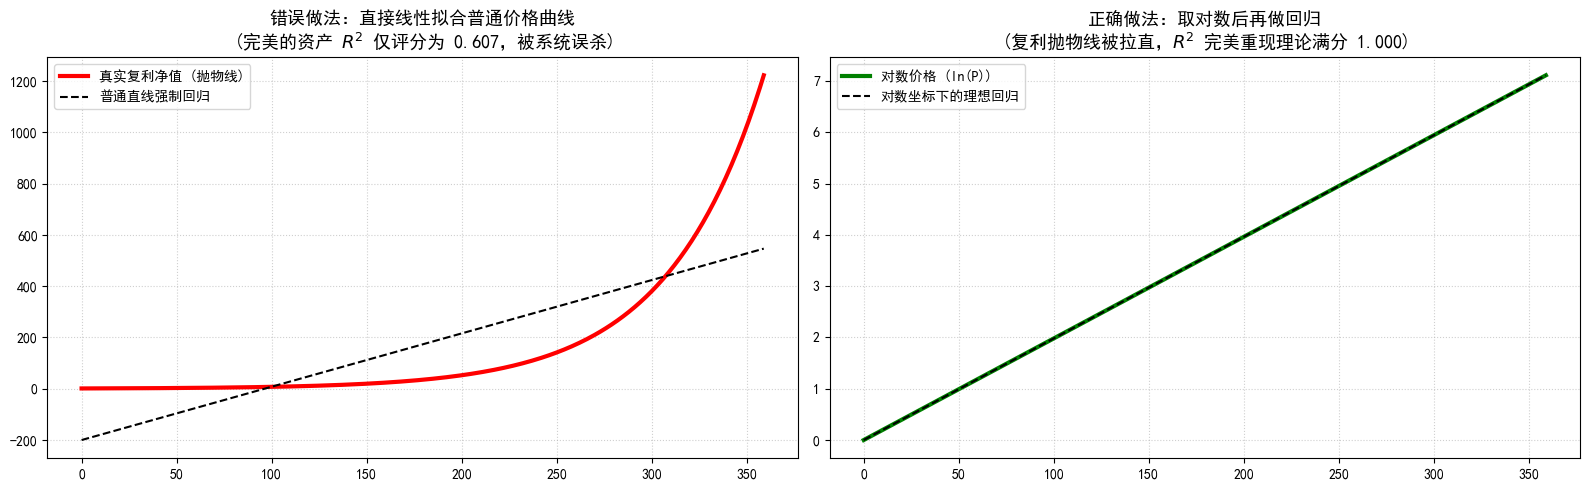

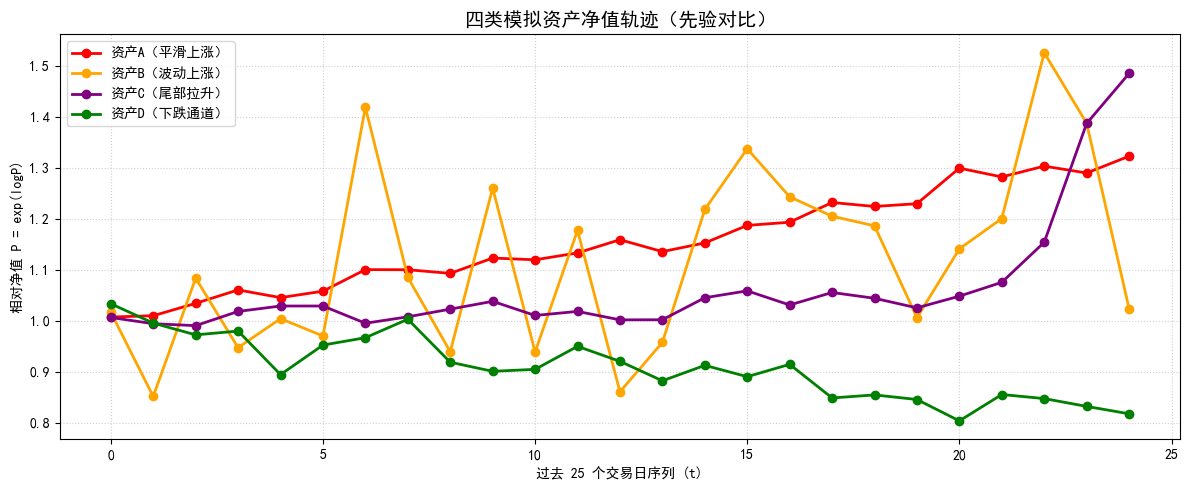


==== 核心公式：绝对动量强度 = (拟合得到的年化收益率) x (衡量趋势稳定性的 R^2 判定系数) ====


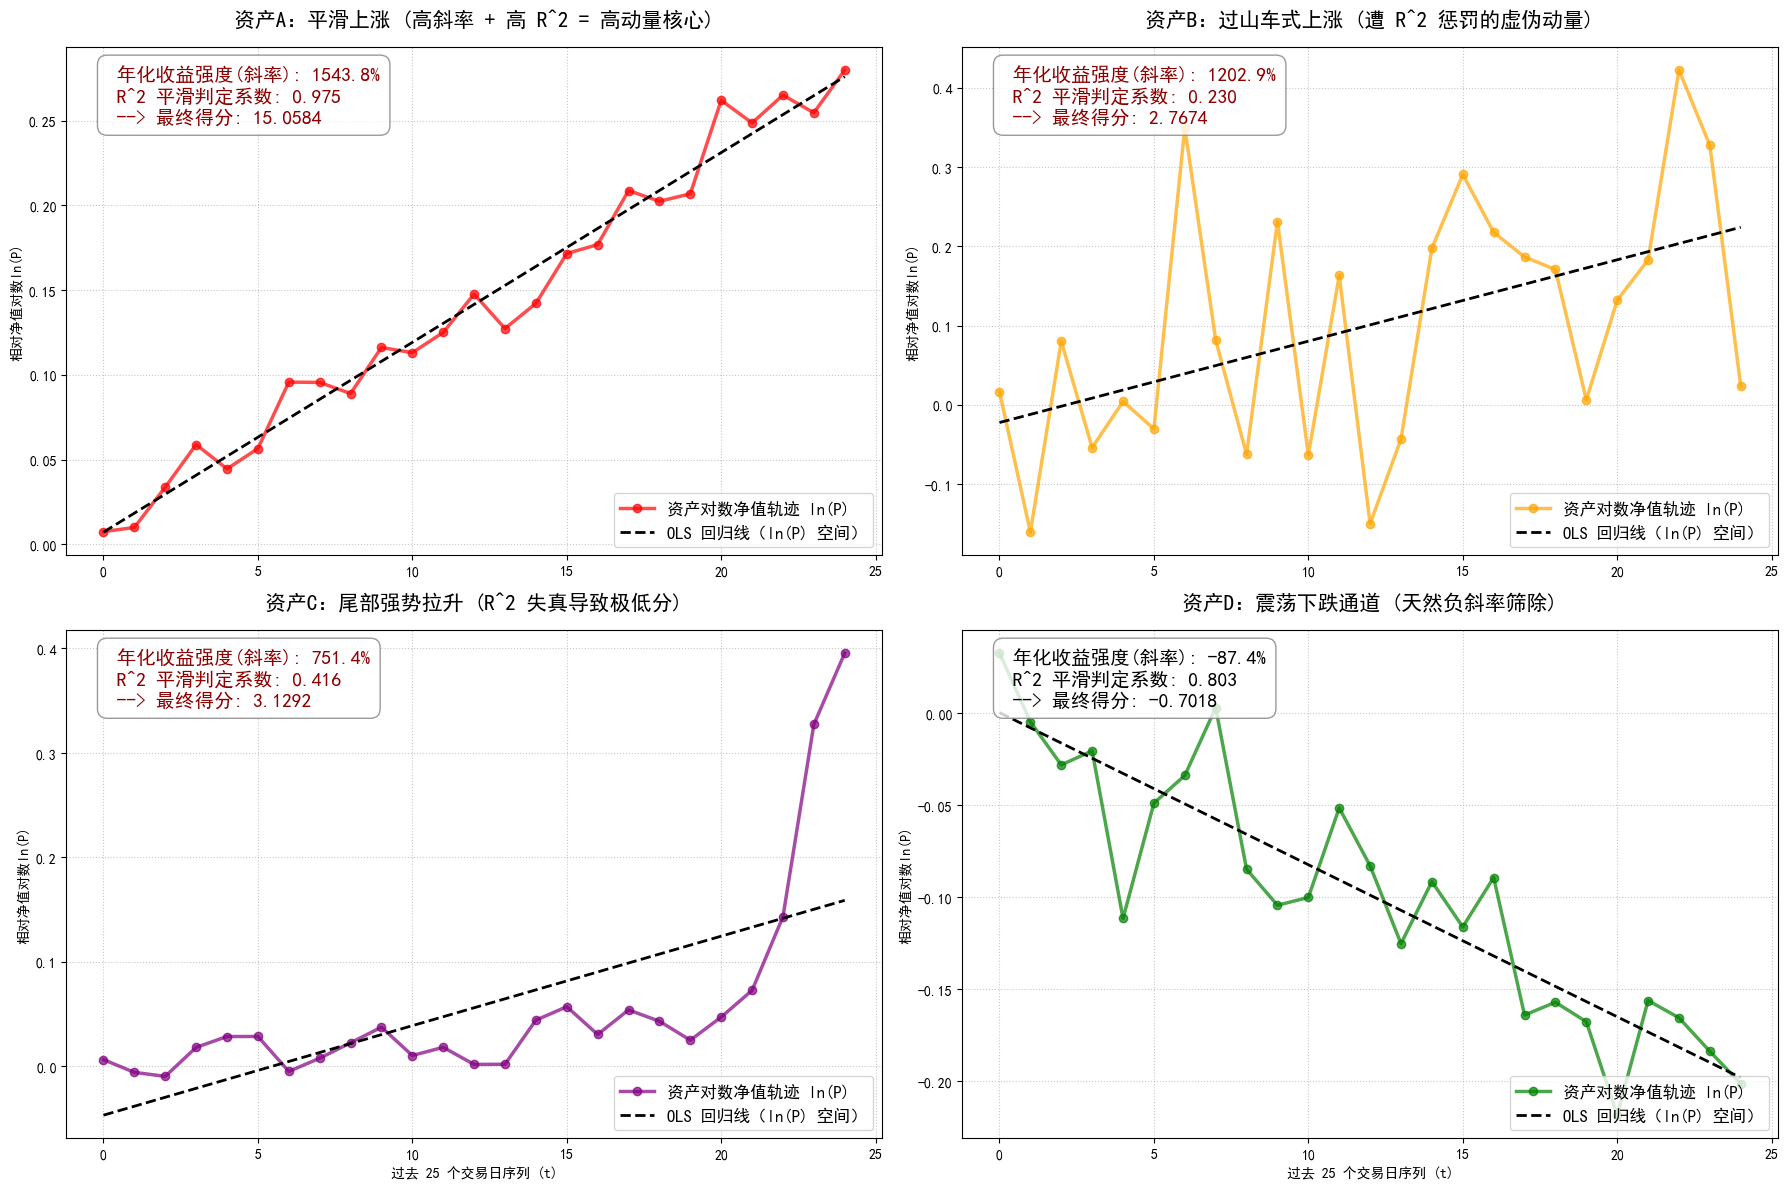

In [3]:
# 【辅助教学说明】运行本单元格，直观感受“取对数的重要性”以及“动量打分系统”的运作原理
import numpy as np
import matplotlib.pyplot as plt
import math

# 配置字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False 

np.random.seed(42)  # 固定随机数种子，使得图像可稳定复现

# =========================================================================
# 教学部分 1：为什么对价格取对数是神来之笔？
# =========================================================================
fig1, (ax1_1, ax1_2) = plt.subplots(1, 2, figsize=(16, 5))

days_log = 360
x_log = np.arange(days_log)
# 模拟一个零波动的完美复利资产，每天涨 2%
perfect_prices = (1.02) ** x_log 

# 用绝对价格强行做线性拟合
slope_norm, intercept_norm = np.polyfit(x_log, perfect_prices, 1)
y_pred_norm = slope_norm * x_log + intercept_norm
r2_norm = 1 - np.sum((perfect_prices - y_pred_norm)**2) / np.sum((perfect_prices - np.mean(perfect_prices))**2)

ax1_1.plot(x_log, perfect_prices, label='真实复利净值 (抛物线)', color='red', linewidth=3)
ax1_1.plot(x_log, y_pred_norm, label='普通直线强制回归', color='black', linestyle='--')
ax1_1.set_title(f"错误做法：直接线性拟合普通价格曲线\n(完美的资产 $R^2$ 仅评分为 {r2_norm:.3f}，被系统误杀)", fontsize=13)
ax1_1.legend()
ax1_1.grid(True, linestyle=':', alpha=0.6)

# 取对数后拟合
log_perfect = np.log(perfect_prices)
slope_log, intercept_log = np.polyfit(x_log, log_perfect, 1)
y_pred_log = slope_log * x_log + intercept_log
r2_log = 1 - np.sum((log_perfect - y_pred_log)**2) / np.sum((log_perfect - np.mean(log_perfect))**2)

ax1_2.plot(x_log, log_perfect, label='对数价格 (ln(P))', color='green', linewidth=3)
ax1_2.plot(x_log, y_pred_log, label='对数坐标下的理想回归', color='black', linestyle='--')
ax1_2.set_title(f"正确做法：取对数后再做回归\n(复利抛物线被拉直，$R^2$ 完美重现理论满分 {r2_log:.3f})", fontsize=13)
ax1_2.legend()
ax1_2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# =========================================================================
# 教学部分 2：不同走势下 R^2 和收益率的乘积过滤效果
# =========================================================================
# 模拟四种典型价格走势，以展示动量因子为何能筛选出真正的强势股：
days = 25
x = np.arange(days)

log_pA = 0.012 * x + np.random.normal(0, 0.015, days)
log_pB = 0.012 * x + np.random.normal(0, 0.150, days)
log_pC = 0.002 * x + np.random.normal(0, 0.02, days)
log_pC[-3:] += [0.1, 0.25, 0.4]  
log_pD = -0.008 * x + np.random.normal(0, 0.04, days)

PA = np.exp(log_pA)
PB = np.exp(log_pB)
PC = np.exp(log_pC)
PD = np.exp(log_pD)

# 先绘制四条模拟净值曲线（便于直观看趋势差异）
fig0, ax0 = plt.subplots(figsize=(12, 5))
ax0.plot(x, PA, marker='o', label='资产A（平滑上涨）', color='red', linewidth=2)
ax0.plot(x, PB, marker='o', label='资产B（波动上涨）', color='orange', linewidth=2)
ax0.plot(x, PC, marker='o', label='资产C（尾部拉升）', color='purple', linewidth=2)
ax0.plot(x, PD, marker='o', label='资产D（下跌通道）', color='green', linewidth=2)
ax0.set_title("四类模拟资产净值轨迹（先验对比）", fontsize=14)
ax0.set_xlabel("过去 25 个交易日序列 (t)")
ax0.set_ylabel("相对净值 P = exp(logP)")
ax0.grid(True, linestyle=':', alpha=0.6)
ax0.legend()
plt.tight_layout()
plt.show()

fig2, axes = plt.subplots(2, 2, figsize=(18, 12))
titles = [
    '资产A：平滑上涨 (高斜率 + 高 R^2 = 高动量核心)', 
    '资产B：过山车式上涨 (遭 R^2 惩罚的虚伪动量)', 
    '资产C：尾部强势拉升 (R^2 失真导致极低分)', 
    '资产D：震荡下跌通道 (天然负斜率筛除)'
]
data = [log_pA, log_pB, log_pC, log_pD]
colors = ['red', 'orange', 'purple', 'green']
axes = axes.flatten()

print("\n==== 核心公式：绝对动量强度 = (拟合得到的年化收益率) x (衡量趋势稳定性的 R^2 判定系数) ====")

for i, ax in enumerate(axes):
    y = data[i]  # 直接使用对数价格序列 ln(P)

    # 对【对数价格序列】做一元线性回归
    slope, intercept = np.polyfit(x, y, 1)
    y_pred = slope * x + intercept

    # 计算 R^2（趋势平滑度）
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r_squared = 1 - (ss_res / ss_tot)

    # 年化收益强度 × R^2
    annualized_returns = math.pow(math.exp(slope), 250) - 1
    momentum_score = annualized_returns * r_squared

    # 画图：不再投影回普通净值空间，全部在 ln(P) 空间展示
    ax.plot(x, y, marker='o', label='资产对数净值轨迹 ln(P)', color=colors[i], alpha=0.7, linewidth=2.5)
    ax.plot(x, y_pred, linestyle='--', label='OLS 回归线（ln(P) 空间）', color='black', linewidth=2)
    
    # 突出文字信息
    ax.set_title(titles[i], fontsize=15, fontweight='bold', pad=15)
    ax.text(0.05, 0.85, f" 年化收益强度(斜率): {annualized_returns*100:.1f}%\n"
                        f" R^2 平滑判定系数: {r_squared:.3f}\n"
                        f" --> 最终得分: {momentum_score:.4f}", 
            transform=ax.transAxes, fontsize=14, color='darkred' if momentum_score>0 else 'black',
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray', boxstyle='round,pad=0.5'))
    
    ax.legend(loc='lower right', fontsize=12)
    ax.grid(True, linestyle=':', alpha=0.7)
    ax.set_ylabel("相对净值对数ln(P)")
    if i >= 2:
        ax.set_xlabel("过去 25 个交易日序列 (t)")

plt.tight_layout()
plt.show()

In [4]:
# 计算动量因子：基于25日对数收益率的线性回归
def calc_momentum_score(price_series):
    """
    计算基于年化收益和判定系数打分的动量因子得分
    对应代码逻辑：
    y = np.log(df.close)
    x = np.arange(df.log.size)
    slope, intercept = np.polyfit(x, y, 1)
    annualized_returns = math.pow(math.exp(slope), 250) - 1
    r_squared = 1 - (sum((y - (slope * x + intercept))**2) / ((len(y) - 1) * np.var(y, ddof=1)))
    """
    y = np.log(price_series)
    x = np.arange(len(y))
    
    # 线性回归得到斜率和截距
    slope, intercept = np.polyfit(x, y, 1)
    
    # 根据斜率计算年化收益
    annualized_returns = math.pow(math.exp(slope), 250) - 1
    
    # 计算 R^2 (由于公式中有基于样本方差的计算，这里直接复原原意)
    y_pred = slope * x + intercept
    ss_res = np.sum((y - y_pred) ** 2)
    # var(ddof=1)是样本方差，乘以(n-1)其实就是离差平方和 ss_tot
    ss_tot = np.sum((y - np.mean(y)) ** 2) 
    
    if ss_tot == 0:
        r_squared = 0
    else:
        r_squared = 1 - (ss_res / ss_tot)
        
    score = annualized_returns * r_squared
    return score

m_days = 25
# 滚动计算每个ETF的动量得分
# 使用 rolling().apply 注意：apply 会逐列传入窗口数据
scores = close_prices.rolling(window=m_days).apply(calc_momentum_score, raw=False)
scores = scores.dropna()

print("动量得分后 5 行：")
display(scores.tail())

动量得分后 5 行：


,518880,513100,159915,510180
date,,,,
2026-03-12,0.026004,-0.329893,-6.744626e-03,-0.000558
2026-03-13,0.217185,-0.318355,-3.245105e-03,-0.000007
2026-03-16,0.240421,-0.298482,-4.641037e-07,-0.000200
2026-03-17,0.056094,-0.328371,-7.751716e-05,-0.019043
2026-03-18,0.008170,-0.280199,2.059922e-04,-0.056874


# 3. 交易回测的核心逻辑与防未来函数泄露

现在，在数据表里，我们已经算好四个 ETF 每天对冲完毕后的那列“动量综合得分”。  
为了模拟真实的资金演变轨迹而不发生逻辑错误，策略循环将严格遵循下面四步机制：

1. **计算当日领头羊信号**：横向对比（`axis=1`），在第 $t$ 天选出四个池子得分最高的那一个，并将其 `id` 做记号。
> **调仓周期说明**：本策略采用**日频决策、次日执行**的调仓机制。  
> 每个交易日收盘后，基于最近 `m_days = 25` 天窗口重新计算动量得分并生成目标持仓；在下一个交易日按该信号持有对应 ETF。若目标资产与前一日一致，则视为继续持有，不发生实际换仓。
3. **每日收益匹配**：我们统计策略每天赚取的利润。也就是去抓取：今天这天我们的信号指标锁定在谁身上，我们就享有该 ETF “今天发生的实际净跌幅百分比”。
4. **净值化计算 ($1+R$复利滚动)**：初始资金设为 $1.0$ 份，使用 `cumprod()` 每天把收益率累乘上去，将抽象收益转化为资金账户里的真实财富成长曲线。

最后，我们将利用 Matplotlib 输出资金走势图，并且单独给出一张**对冲指数化的对数图（Log Scale）**。因为当面对纳指这样动辄翻十倍几十倍的高息暴利资产时，线性的图表最终会像火箭升空般被压缩在屏幕下方，普通视图会失去所有的观察功能，而对数轴则能精准体现它真正的复合波动质感。

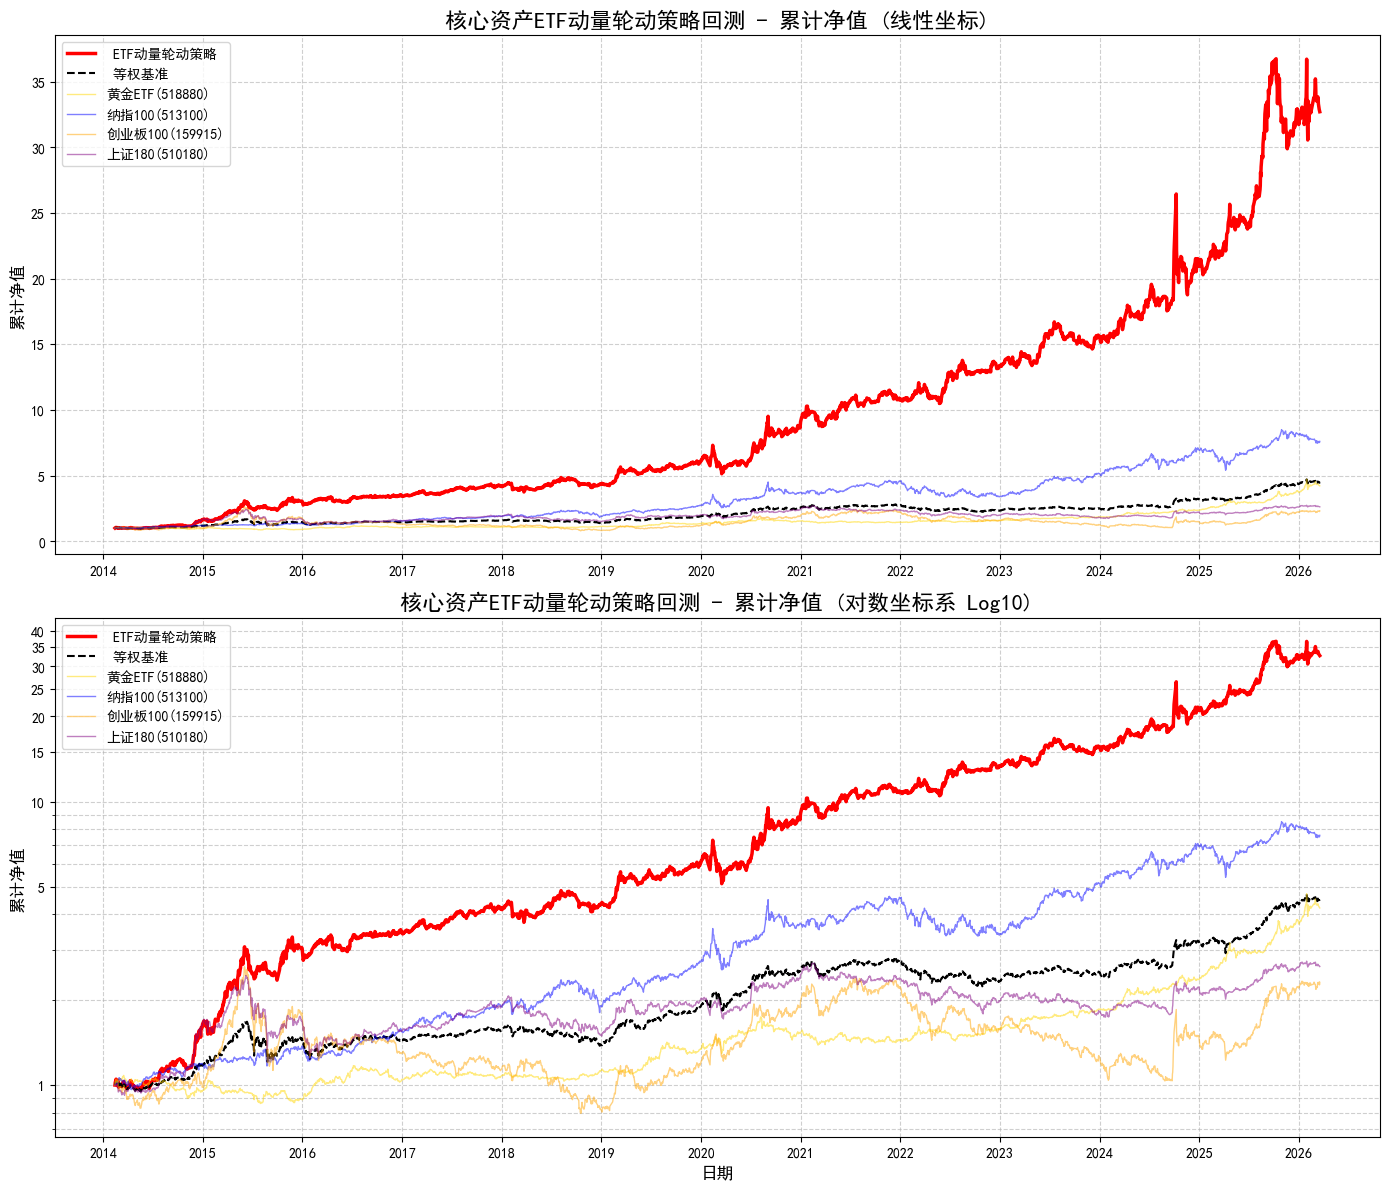

,累计收益,年化收益,年化波动,夏普比率,最大回撤
轮动策略,3049.14%,34.39%,26.33%,1.31,29.71%
等权基准,343.46%,13.61%,15.61%,0.87,27.70%
黄金ETF,320.71%,13.10%,14.43%,0.91,20.47%
纳指100,655.49%,18.92%,21.48%,0.88,28.57%
创业板100,121.65%,7.06%,33.44%,0.21,69.58%
上证180,161.46%,8.58%,21.43%,0.40,46.94%


In [5]:
# 交易逻辑与回测
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
from matplotlib.ticker import FuncFormatter
# 中文显示设置（matplotlib）
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False
# 1. 每日收益率
daily_returns = close_prices.pct_change()

# 2. 确定每日持仓信号
# 在第 t 天收盘后计算好 scores，选出最大值作为 target
target_asset = scores.idxmax(axis=1)

# 为了在回测中模拟真实的交易：我们在第 t 天发出的信号，第 t+1 天才去持有获取收益。
# 因此，我们将 target_asset 往后 shift 1 天
hold_signal = target_asset.shift(1)
# 截取有效日期范围（去掉前期缺失动量得分和信号偏移带来的缺失）
valid_dates = hold_signal.dropna().index
hold_signal = hold_signal.loc[valid_dates]

# 3. 计算策略收益
# 创建一个空的 Series 用来存放策略每天的收益率
strategy_returns = pd.Series(0.0, index=valid_dates)

for code in daily_returns.columns:
    # 策略收益 = 在持有该 ETF 的当天的真实收益率
    mask = (hold_signal == code)
    strategy_returns[mask] = daily_returns.loc[valid_dates, code][mask]

# 4. 计算净值
# 策略净值
strategy_nav = (1 + strategy_returns).cumprod()
strategy_nav = strategy_nav / strategy_nav.iloc[0]  # 归一化到 1

# 等权重基准净值（4个ETF等权重）
benchmark_returns = daily_returns.mean(axis=1).loc[valid_dates]
benchmark_nav = (1 + benchmark_returns).cumprod()
benchmark_nav = benchmark_nav / benchmark_nav.iloc[0]

# 单个ETF净值
asset_navs = {}
for code in daily_returns.columns:
    nav = (1 + daily_returns[code].loc[valid_dates]).cumprod()
    asset_navs[code] = nav / nav.iloc[0]

# 5. 可视化绘制净值曲线与对数极坐标曲线
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))

# --- 线性区间轴净值曲线 ---
ax1.plot(strategy_nav.index, strategy_nav, label=' ETF动量轮动策略', color='red', linewidth=2.5)
ax1.plot(benchmark_nav.index, benchmark_nav, label=' 等权基准', color='black', linestyle='--', linewidth=1.5)

colors = ['gold', 'blue', 'orange', 'purple']
for i, (code, name) in enumerate(etf_pool.items()):
    ax1.plot(asset_navs[code].index, asset_navs[code], label=f'{name}({code})', alpha=0.5, linewidth=1, color=colors[i])

ax1.set_title('核心资产ETF动量轮动策略回测 - 累计净值 (线性坐标)', fontsize=16)
ax1.set_ylabel('累计净值', fontsize=12)
ax1.xaxis.set_major_locator(mdates.YearLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax1.yaxis.set_major_locator(ticker.MultipleLocator(5.0)) # Y 轴每隔 5 标记一次
ax1.legend(loc='upper left')
ax1.grid(True, linestyle='--', alpha=0.6)

# --- 对数区间轴（Log Scale）净值曲线 ---
ax2.plot(strategy_nav.index, strategy_nav, label=' ETF动量轮动策略', color='red', linewidth=2.5)
ax2.plot(benchmark_nav.index, benchmark_nav, label=' 等权基准', color='black', linestyle='--', linewidth=1.5)

for i, (code, name) in enumerate(etf_pool.items()):
    ax2.plot(asset_navs[code].index, asset_navs[code], label=f'{name}({code})', alpha=0.5, linewidth=1, color=colors[i])

ax2.set_yscale('log') # 设置Y轴为10为底的对数坐标系

# 设置格式系：将纵坐标显示为普通的数字(1, 2, 10 等)，而非10^x格式
ax2.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:g}"))
# 添加固定的主刻度：在对数图上手动制定想要标记的值（1, 5, 10, 15, 20...）
# 取最大对数净值然后按每隔 5 设置一个固定的 tick 列表，因为对数轴 MultipleLocator 往往无效
max_nav = int(strategy_nav.max()) + 1
ticks = [1] + list(range(5, max_nav + 5, 5)) 
ax2.set_yticks(ticks)

ax2.set_title('核心资产ETF动量轮动策略回测 - 累计净值 (对数坐标系 Log10)', fontsize=16)
ax2.set_xlabel('日期', fontsize=12)
ax2.set_ylabel('累计净值', fontsize=12)
ax2.xaxis.set_major_locator(mdates.YearLocator())
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax2.legend(loc='upper left')
ax2.grid(True, linestyle='--', alpha=0.6, which='both') # 对数轴开启 both (包含次刻度线) 使得对数比例轴更直观

plt.tight_layout()
plt.show()

# 6. 基本指标输出
def calc_metrics(returns):
    cumulative_return = (returns + 1).prod() - 1
    annual_return = (cumulative_return + 1) ** (252 / len(returns)) - 1
    annual_volatility = returns.std() * np.sqrt(252)
    sharpe_ratio = annual_return / annual_volatility if annual_volatility > 0 else 0
    max_drawdown = (1 - (returns + 1).cumprod() / (returns + 1).cumprod().cummax()).max()
    return {
        "累计收益": f"{cumulative_return*100:.2f}%",
        "年化收益": f"{annual_return*100:.2f}%",
        "年化波动": f"{annual_volatility*100:.2f}%",
        "夏普比率": f"{sharpe_ratio:.2f}",
        "最大回撤": f"{max_drawdown*100:.2f}%"
    }

metrics = {
    "轮动策略": calc_metrics(strategy_returns),
    "等权基准": calc_metrics(benchmark_returns),
}
for code, name in etf_pool.items():
    metrics[name] = calc_metrics(daily_returns[code].loc[valid_dates])

metrics_df = pd.DataFrame(metrics).T
display(metrics_df)

正在计算参数平原，请稍候...


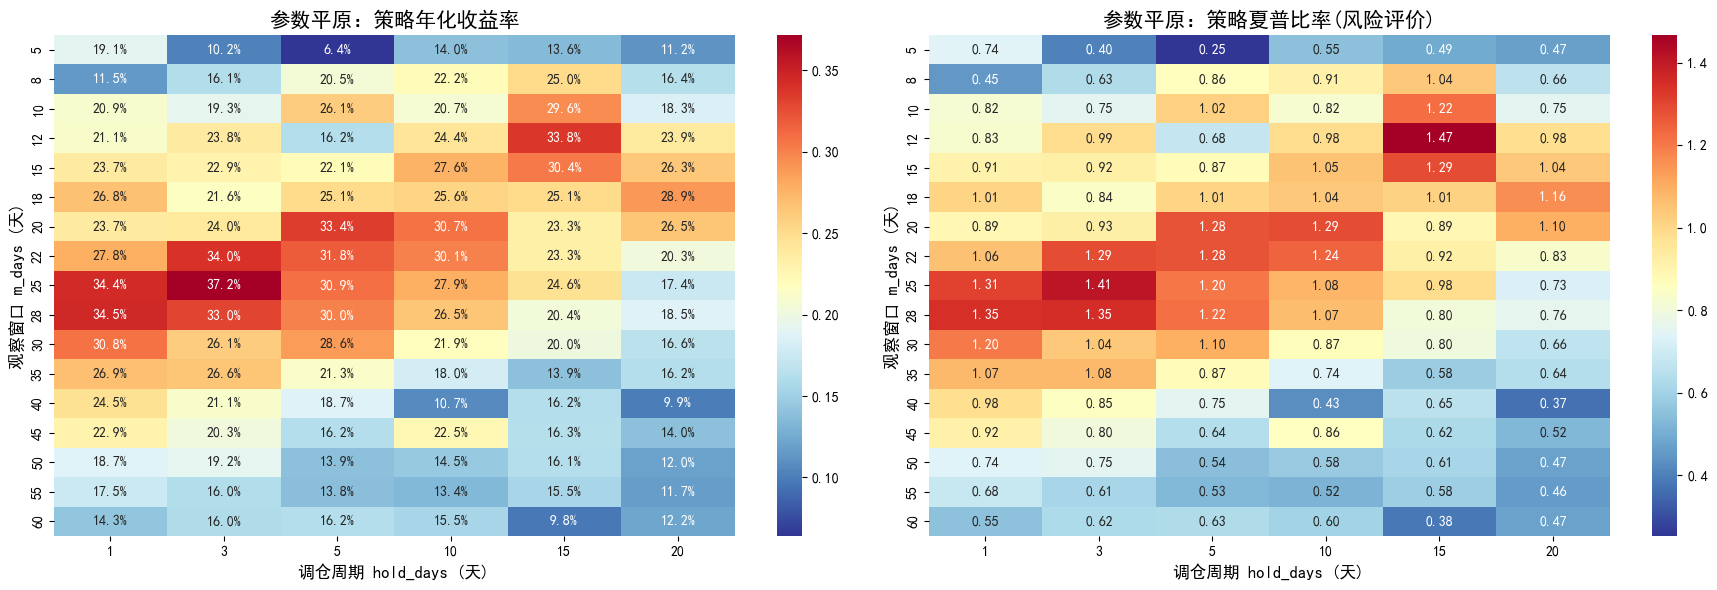

In [9]:
import seaborn as sns
import numpy as np

# --- 寻找参数平原：计算不同 m_days 和 hold_days 组合的年化收益率与夏普比率 ---
m_days_list = [5, 8, 10, 12, 15, 18, 20, 22, 25, 28, 30, 35, 40, 45, 50, 55, 60]
hold_days_list = [1, 3, 5, 10, 15, 20]

# 准备两个空矩阵存放结果
return_matrix = np.zeros((len(m_days_list), len(hold_days_list)))
sharpe_matrix = np.zeros((len(m_days_list), len(hold_days_list)))

# 提前准备好日收益率
daily_rtn = close_prices.pct_change()

print("正在计算参数平原，请稍候...")
for i, m_d in enumerate(m_days_list):
    # 针对不同动量观察窗口重新计算得分
    # 为加速这里复用了上文定义的 calc_momentum_score 
    scores_md = close_prices.rolling(window=m_d).apply(calc_momentum_score, raw=False).dropna()
    target_asset_md = scores_md.idxmax(axis=1)
    
    for j, h_d in enumerate(hold_days_list):
        # 调仓周期逻辑：每隔 h_d 天去取一次信号，并向后延续 (ffill)
        rebalance_dates = target_asset_md.iloc[::h_d].index
        signal = target_asset_md.loc[rebalance_dates].reindex(target_asset_md.index).ffill().shift(1).dropna()
        
        valid_d = signal.index
        
        strat_rtn = pd.Series(0.0, index=valid_d)
        for code in daily_rtn.columns:
            mask = (signal == code)
            strat_rtn[mask] = daily_rtn.loc[valid_d, code][mask]
            
        # 计算该组合的年化收益率
        cum_ret = (strat_rtn + 1).prod() - 1
        ann_ret = (cum_ret + 1) ** (252 / len(strat_rtn)) - 1
        return_matrix[i, j] = ann_ret
        
        # 计算该组合的夏普比率
        ann_vol = strat_rtn.std() * np.sqrt(252)
        sharpe = ann_ret / ann_vol if ann_vol > 0 else 0
        sharpe_matrix[i, j] = sharpe

# --- 画出参数平原热力图 ---
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# 图1：年化收益率热力图
sns.heatmap(return_matrix, annot=True, fmt=".1%", cmap="RdYlBu_r", 
            xticklabels=hold_days_list, yticklabels=m_days_list, ax=axes[0])
axes[0].set_title('参数平原：策略年化收益率', fontsize=15)
axes[0].set_xlabel('调仓周期 hold_days (天)', fontsize=12)
axes[0].set_ylabel('观察窗口 m_days (天)', fontsize=12)

# 图2：夏普比率热力图
sns.heatmap(sharpe_matrix, annot=True, fmt=".2f", cmap="RdYlBu_r", 
            xticklabels=hold_days_list, yticklabels=m_days_list, ax=axes[1])
axes[1].set_title('参数平原：策略夏普比率(风险评价)', fontsize=15)
axes[1].set_xlabel('调仓周期 hold_days (天)', fontsize=12)
axes[1].set_ylabel('观察窗口 m_days (天)', fontsize=12)

plt.tight_layout()
plt.show()

In [7]:
# 查看最近 N 个交易日的持仓
recent_n = 5
recent_holdings = hold_signal.dropna().tail(recent_n)

recent_df = pd.DataFrame({
    "持仓代码": recent_holdings,
    "持仓名称": recent_holdings.map(etf_pool)
})
display(recent_df)

# 查看最新持仓
if not recent_holdings.empty:
    latest_date = recent_holdings.index[-1]
    latest_code = recent_holdings.iloc[-1]
    latest_name = etf_pool.get(latest_code, "未知")
    print(f"最新持仓日期: {latest_date.date()} | 持仓: {latest_name} ({latest_code})")

,持仓代码,持仓名称
date,,
2026-03-12,518880,黄金ETF
2026-03-13,518880,黄金ETF
2026-03-16,518880,黄金ETF
2026-03-17,518880,黄金ETF
2026-03-18,518880,黄金ETF


最新持仓日期: 2026-03-18 | 持仓: 黄金ETF (518880)
